In [6]:
import re
import numpy as np
import pandas as pd

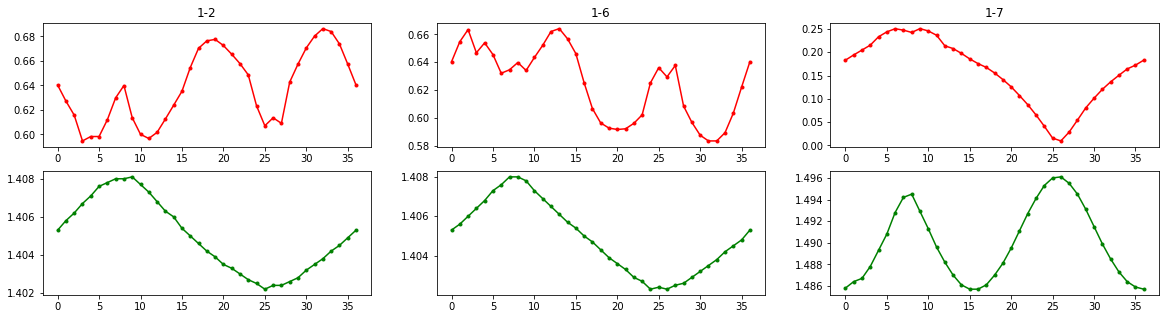

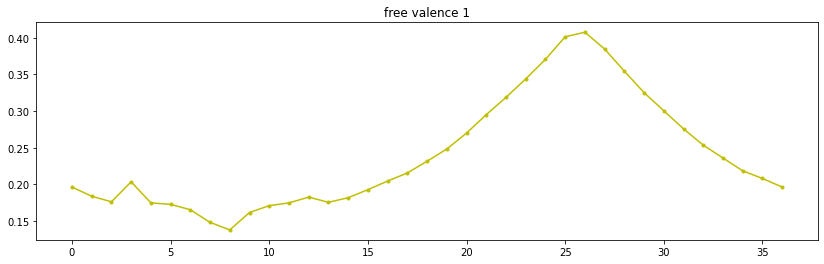

In [71]:
# 联苯键级键角图
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def get_wfnOrders(atom1,atom2):
    with open(r"C:\code\HFV\files\benScan\benScanMfn.txt",'r',encoding='utf-8') as f:
        data=f.read()
    wfnOrders=re.findall(r'# +\d: +'+f'{atom1}'+'\(C \)    '+f'{atom2}'+'\(C \) +(\d.\d{8})',data)
    wfnOrders=np.array(wfnOrders,dtype=np.float32)
    return wfnOrders
def get_bondOrders(atom1,atom2):
    with open(r"RES30.txt",'r',encoding='utf-8') as f:
        data=f.read()
    datas=data.split('----------------------------------------------------------------------')[1:]
    all_res=[]
    all_valence=[]
    for each in datas:
        res=re.search(f'{atom1}->{atom2}'+r',bond order:(-?\d.\d{4}),bond length:(-?\d.\d{4})',each)
        valence=re.search(r'free valence:(-?\d.\d{4})',each).groups()
        if res is not None:
            all_res.append(res.groups())
        else:
            all_res.append([0,0])
        all_valence.append(valence)
    bondOrders=pd.DataFrame(all_res,dtype=float).to_numpy()[:,0]
    bondLengths=pd.DataFrame(all_res,dtype=float).to_numpy()[:,1]
    atomValence=pd.DataFrame(all_valence,dtype=float).to_numpy().flatten()
    return bondOrders,bondLengths,atomValence
fig,a=plt.subplots(2,3,figsize=(20, 5))
arounds=[2,6,7]
for i in range(3):
    around=arounds[i]
    bondOrders,bondLengths,atomValence=get_bondOrders(1,around)
    a[0][i].set_title(f'1-{around}')
    # a[0][i].plot(np.arange(len(atomValence)),atomValence,'y.-')
    a[0][i].plot(np.arange(len(bondOrders)),bondOrders,'r.-')
    a[1][i].plot(np.arange(len(bondLengths)),bondLengths,'g.-')
    # wfnOrders=get_wfnOrders(1,around)
    # a[2][i].plot(np.arange(len(wfnOrders)),wfnOrders,'b.-')
# a[0].plot(np.arange(len(atomValence)),atomValence[::-1],'y.-')
# a[1].plot(np.arange(len(bondOrders)),bondOrders[::-1],'r.-')
# a[2].plot(np.arange(len(bondLengths)),bondLengths[::-1],'g.-')
# a[3].plot(np.arange(len(wfnOrders)),wfnOrders[::-1],'b.-')
fig,a=plt.subplots(figsize=(14, 4))
a.set_title('free valence 1')
a.plot(np.arange(len(atomValence)),atomValence,'y.-')

In [8]:
import numpy as np
p2=np.array([-0.2384,-0.0520,0.0])
p3=np.array([-0.1482,-0.0311,0.0])
n=np.array([-0.4467,-0.1032,0.0])
p2/np.linalg.norm(p2),p3/np.linalg.norm(p3),n/np.linalg.norm(n),(p2*3+p3)/np.linalg.norm(p2*3+p3)

(array([-0.97702817, -0.21311017,  0.        ]),
 array([-0.97868271, -0.20537809,  0.        ]),
 array([-0.97433602, -0.22509845,  0.        ]),
 array([-0.97731611, -0.21178578,  0.        ]))

In [9]:
p2=np.array([-0.22434,-0.00109,-0.04604])
p3=np.array([-0.14881,-0.00035,-0.02730])
n=np.array([-0.449293,-0.002107,-0.091544])
p2/np.linalg.norm(p2),p3/np.linalg.norm(p3),n/np.linalg.norm(n),(p2*3+p3)/np.linalg.norm(p2*3+p3)

(array([-0.97957309, -0.00475945, -0.20103212]),
 array([-0.98358262, -0.00231338, -0.18044356]),
 array([-0.97985709, -0.00459513, -0.19964709]),
 array([-0.980329  , -0.00431816, -0.19732308]))

In [24]:
p2.round(2).tolist()

[-0.22, -0.0, -0.05]

In [17]:
import numpy as np
import re
import matplotlib.pyplot as plt

In [11]:
with open(r"C:\code\HFV\logs\2022-06-21-09-54-12.txt",'r',encoding='utf-8') as f:
    data=f.read()

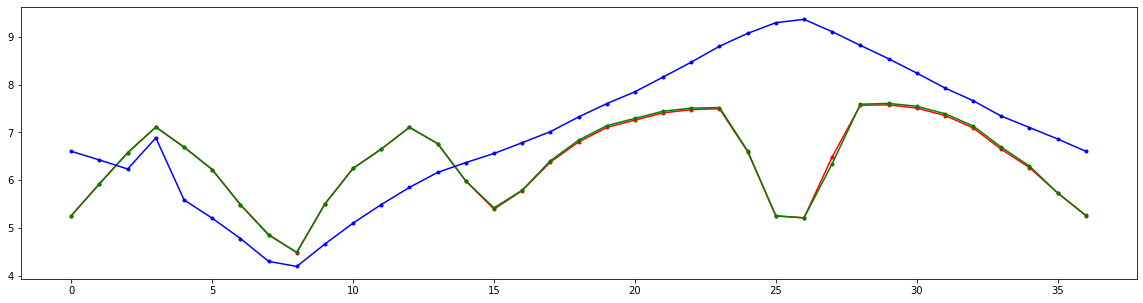

In [68]:
res=re.findall(r'^RatiosSum:(\d+.\d+),(\d+.\d+)',data,re.MULTILINE)
res=re.findall(r'centerRatiosSum:(\d+.\d+),(\d+.\d+)',data,re.MULTILINE)
res=np.array(res,dtype=np.float32)
y=res[:,0]
y1=[]
y2=[]
y3=[]
for i in range(0,len(y),3):
    y1.append(y[i])
    y2.append(y[i+1])
    y3.append(y[i+2])
fig,a=plt.subplots(figsize=(20, 5))
a.plot(np.arange(len(y1)),y1,'r.-')
a.plot(np.arange(len(y2)),y2,'g.-')
a.plot(np.arange(len(y3)),y3,'b.-')

In [64]:
res.shape

(0,)

In [49]:
np.mean(y1),np.mean(y2),np.mean(y3)

(6.5918756, 6.633928, 13.225803)

In [56]:
len(y1)

37